# Implementing Logistic Regression From Scratch

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.utils import shuffle
from sklearn.datasets import load_iris
from sklearn.preprocessing import Normalizer

## Loading our test data
We're going to use the iris dataset for our example. It is a collection of stem and petal measurements for three different types of irises. The objective of this dataset is to identify the type of iris based on the measurements.

<div style="margin:auto;width:50%">

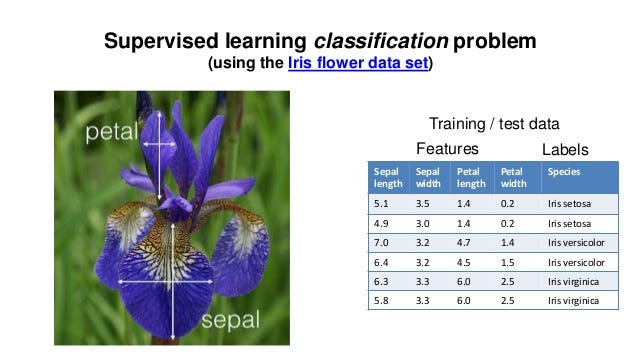

<p>Source: https://medium.com/analytics-vidhya/exploration-of-iris-dataset-using-scikit-learn-part-1-8ac5604937f8</p>

</div>

----
## Setting up our expirement

To keep our example simple, we'll limit our test data to:
 - Two features or measurements
   - This to make it easier to visaulize our data
 - Two types of irises
   - This way we can focus on binary classification as multi-class classification requires a more complex model (or multiple models)

In [2]:
iris_data = load_iris()

The iris dataset is built into the scikit-learn library, which the above function leverages. This loads the data into a custom object type, but we'll just focus on the `data` or **independent variables** and `target` or **dependent variables**.

In [3]:
# The below logic states to take : (all rows), :2 (first two columns)
feats = iris_data['data'][:,:2]
class_labels = iris_data['target']

X = feats
y = class_labels

## Reducing our dataset to two classes
The iris dataset typically contains 3 types of irises - setosa, versicolor, virginica. However, logistic regression is a binary classification system. To make our data work, we'll remove one of the classes from our dataset.

In [4]:
set(iris_data['target_names'])

{'setosa', 'versicolor', 'virginica'}

In [5]:
set(y)

{0, 1, 2}

Our target variable (y) has three values [0, 1, 2]. So by selecting all the rows for one of the classes, `np.where(y==2)`, we can remove those rows from our data.

In [6]:
bad_ixs = np.where(y == 2)
X = np.delete(X, bad_ixs, axis=0)
y = np.delete(y, bad_ixs, axis=0)

In [7]:
set(y)

{0, 1}

## Plot our test data
Lets plot the test data to verify everything is in order

Text(0.5, 1.0, 'Iris Types by Stem and Petal')

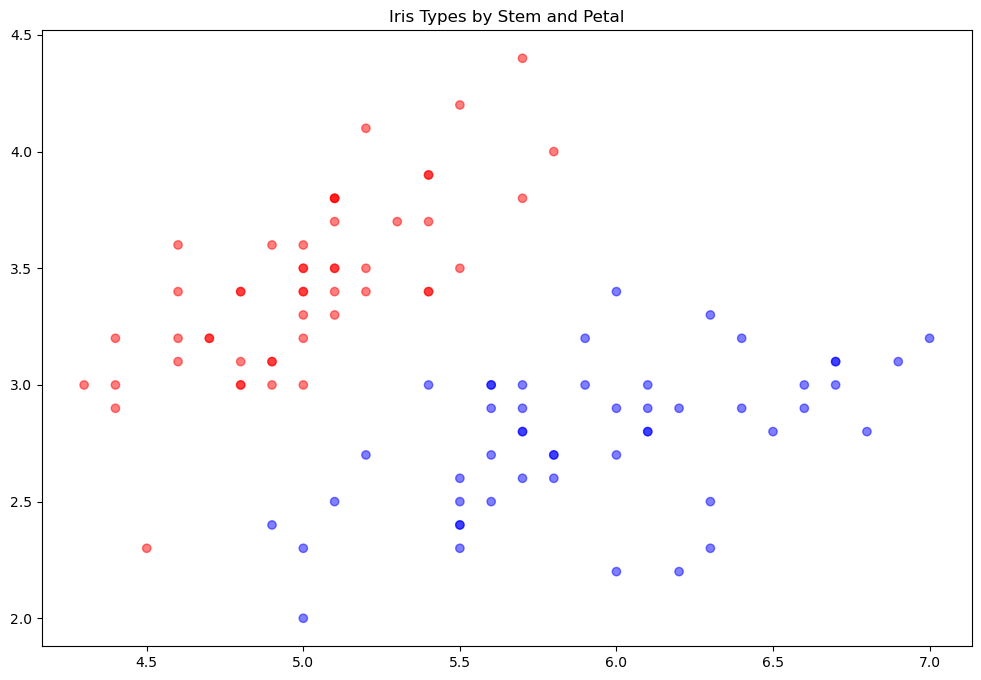

In [8]:
colors = ['red' if x == 0 else 'blue' for x in y]
plt.figure(figsize=(12,8))
plt.scatter(X[:, 0], X[:, 1], c = colors, alpha = 0.5)
plt.title("Iris Types by Stem and Petal")

## Prep and Initailize Our Inputs

In [9]:
from sklearn.model_selection import train_test_split

# Lets randomly split things into training and testing sets so we don't cheat
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [10]:
X_train.shape

(67, 2)

In [11]:
y_train.shape

(67,)

### **Question: Why do we add a bias/intercept term for logistic regression?**

<details>
<summary>Answer:</summary>

Given the formula $y = B_0*X_1 + .... + B_n*X_n$:
 - When all $inputs = X_{1..n} = 0$ then $y = 0$
 - In most real world situations when $inputs = X_{1..n} = 0$, $y \neq 0$

<div style="margin:auto;width:60%;">

![1 XiVKEj5ZmTfgWOn4C0N84Q.png](<attachment:1 XiVKEj5ZmTfgWOn4C0N84Q.png>)

<p style="text-align:center">Source:https://medium.com/@shivangisareen/linear-regression-least-squares-bc2ac1e6a3aa</p>
</div>

</details>

## Support Functions
To build our logistic model we'll need a couple of support functions:
 - **sigmoid**: The final stage of our computational graph requires taking the logistic function of our outputs
$$\frac{1}{1+ e^{-z}} $$
 - **log_likelihood**: Our loss function for our logistic regression
   - Recall that loss functions are necessary for gradient descent
$$\sum{1 + Y*\log{(\frac{1}{1+e^{-z}})}}$$

**In Class: Complete the functions**

In [43]:
# Update scores param to Z
def sigmoid(Z):
    """Take our scores and apply the sigmoid function
    Args:
        scores(np.array): Weighted inputs
    Returns: 
        np.array: Sigmoid output of weighted features
    """
    return(1 / (1 + np.exp(-Z)))

def log_likelihood(Z, W):
    """Take our inputs, outputs, and weights and determine
    the logistic log-likelihood. This will be used to understand
    our models progress.
    Args:
        X (np.array): Features/indepednent variables
        Y (np.array): Classes/dependent variables
        W (np.array): Model weights
    Returns:
        float: log-likelihood of X, Y, W
    """
    log_like = np.sum(1+y_test*np.log(1/(1+np.exp(-Z))))
    return(-log_like)

## Logistic Regression Function
Putting together what we've talked about, and leveraging the support functions, we can build our own logisitc regression function.

 - **Gradient**: As covered in the slides, the gradient for the inverse log-likelihood is:
 $$\frac{dloss}{dw} = (\hat{y} - y) * x$$

**In Class: Add the logic for the gradient calculation**

In [48]:
def logistic_regression(X, y, num_steps, learning_rate, add_intercept=False):
    """Implementaiton of the logistic_regression algorithm.
    Args:
        X (np.array): Features/indepednent variables
        Y (np.array): Classes/dependent variables
        num_steps (int): Number of iterations through the training dataset
        learning_rate (float): Learning rate for gradient descent
        intercept (boolean): Is there an intercept term for our model
    returns:
        np.array: Weights for each feature/intercept
        list: List containing all weights generated during training
    """
    # Done to avoid any manipulation of the original X and y
    lr_X = X_test
    lr_y = y_test
    weights_history = []
    
    if add_intercept:
        # Our intecept weigth B0 can be represented as X0*B0 where X0 is 1
        intercept = np.ones((lr_X.shape[0], 1))
        # So by stacking on 1's to our array, we've created a placeholder for B0
        lr_X = np.hstack((intercept, lr_X))
        W = np.random.randn(3) 
    else:
        # Initialize our weights
        W = np.random.randn(2) 
        

    
    for step in range(num_steps):
        
        # Calculate the predictions for each record
        
        Z = np.dot(lr_X,W)
        y_hat = preds = sigmoid(Z)
        
        # Calculate error
        
        error = (y_hat - y)
        

        # Space for gradient calculation
        
        gradient = np.dot(lr_X.T , error) 
        gradient /= lr_X.shape[0]

        
        # Update our weights based on the calculated gradient
        
        W = W - learning_rate * gradient
        
        # Print log-likelihood every so often
        if step % 5 == 0:
            print(gradient)
            print(log_likelihood(Z, W))
            weights_history.append(W.copy())
            
    # Copy the current weights for review        
    if num_steps % 10 != 0:
        weights_history.append(W.copy())
        
    return W, weights_history

In [ ]:
accuracy = (weights * X_test)

### Running our Model
Once we've completed our regression function we can pass in our X and y values to evaluate how well we can train a model.

In [49]:
# Calculate what weights optimize our logistic regression function|
intercept = True
weights, history = logistic_regression(X_test, y_test, num_steps = 80, learning_rate = .01, add_intercept=intercept)
print(f'\nGenerated weights:\n{weights}')

[-0.40834144 -2.43192295 -1.12387738]
49.09095330533654
[-0.38936348 -2.33522604 -1.05790379]
36.7887571478024
[-0.35326669 -2.15012696 -0.93227821]
25.285739158402226
[-0.29659742 -1.85762215 -0.73567814]
15.186277806294038
[-0.2272536  -1.49729962 -0.49713365]
7.048540293075751
[-0.16032604 -1.14714263 -0.26969636]
1.0251796152321382
[-0.10584316 -0.86015068 -0.08695218]
-3.1743287331184855
[-0.0657212  -0.64746121  0.04602361]
-6.016775336917288
[-0.03771921 -0.49815858  0.13785993]
-7.926929491276355
[-0.01872348 -0.39630966  0.19955182]
-9.219615640421003
[-0.00603839 -0.32788552  0.24032317]
-10.109150895050444
[ 0.0023525 -0.2822885  0.2669506]
-10.736598349168576
[ 0.0078671  -0.25201927  0.28414496]
-11.193723372252101
[ 0.01147294 -0.23193889  0.29509681]
-11.54004207078782
[ 0.01381965 -0.21858702  0.30193785]
-11.814150511537624
[ 0.01533928 -0.2096578   0.30608115]
-12.041089459449223

Generated weights:
[-0.61292972 -0.72153046  1.32431499]


In [46]:
# Calculate what weights optimize our logistic regression function
intercept = True
weights, history = logistic_regression(X, y, num_steps = 80, learning_rate = .01, add_intercept=intercept)
print(f'\nGenerated weights:\n{weights}')

[-0.3469906  -2.1182488  -0.91299427]
21.98043591910185
[-0.28747808 -1.81079287 -0.70842446]
12.14220744679375
[-0.21654687 -1.44152435 -0.46646313]
4.347107669528861
[-0.14976268 -1.09117258 -0.24116901]
-1.314769011335904
[-0.09655544 -0.81002483 -0.06381007]
-5.19114755222358
[-0.05810335 -0.60552905  0.06295631]
-7.773078832002348
[-0.03172145 -0.46441005  0.1490689 ]
-9.484733498240281
[-0.01411045 -0.36967304  0.20599537]
-10.630398203777437
[-0.00253148 -0.30698874  0.24301335]
-11.412408445542786
[ 0.00501182 -0.26581917  0.2667841 ]
-11.961487511826428
[ 0.00989498 -0.23886214  0.28185403]
-12.361319226379088
[ 0.01304004 -0.22120482  0.29125188]
-12.665376884150248
[ 0.01505587 -0.20959498  0.29696974]
-12.907842153129428
[ 0.01634099 -0.20190042  0.30030804]
-13.110577917781747
[ 0.01715475 -0.19673212  0.30211152]
-13.28757070295329
[ 0.01766517 -0.19318925  0.30292693]
-13.447765769764722

Generated weights:
[ 0.02777681 -0.70124959  1.09518684]


### In Class Exercise
Use the given weights to draw the decision boundary for our trained model.

*Hint: Logistic regression states - $p(y^i) = B_0 + B_1*X_1 + ... + B_n*X_n$. This means we can identify the inputs for a specific probability (0.5) by setting - $p(y^i) = 0.5$.*